# BÀI 1: XÂY DỰNG MÔ HÌNH TRANSFORMER TỪ ĐẦU (FROM SCRATCH)

Đề tài: Xây dựng hệ thống tóm tắt văn bản tự động.
Phương pháp: Tự lập trình kiến trúc Transformer hoàn toàn từ đầu (Encoder, Decoder, Attention, FFN) và huấn luyện trên tập dữ liệu tiếng Việt.

In [1]:
!pip install -q sentencepiece rouge-score sacrebleu bert-score gdown

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 100.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.

In [2]:
import os, math, json, random, gc, time, glob
from pathlib import Path
from dataclasses import dataclass
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

def free_mem():
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

def detect_env():
    if os.path.exists('/kaggle') or os.environ.get('KAGGLE_KERNEL_RUN_TYPE'):
        return 'kaggle'
    try:
        import google.colab  # noqa
        if os.path.exists('/content'): return 'colab'
    except Exception:
        pass
    return 'local'
ENV = detect_env(); print('ENV =', ENV)

Device: cuda
GPU: Tesla T4
ENV = kaggle


## 1. Cấu hình siêu tham số (Hyperparameters)


In [3]:
ROOT = Path('/kaggle/working') if ENV=='kaggle' else (Path('/content') if ENV=='colab' else Path('.'))
WORK = ROOT / 'nlp_bai1'

@dataclass
class Config:
    data_dir: Path = WORK/'data'; ckpt_dir: Path = WORK/'ckpt'
    vocab_size: int = 16000
    pad_id: int = 0; unk_id: int = 1; bos_id: int = 2; eos_id: int = 3
    max_src_len: int = 384; max_tgt_len: int = 96
    # Model dimensions
    d_model: int = 512; nhead: int = 8; num_layers: int = 6; d_ff: int = 2048; dropout: float = 0.15

    norm_first: bool = True          # Pre-LN
    use_rope: bool = True            # RoPE thay sinusoidal
    # Training config
    batch_size: int = 16; accum_steps: int = 4; num_epochs: int = 20
    label_smoothing: float = 0.1; warmup_steps: int = 1500; grad_clip: float = 1.0; use_amp: bool = True
    # Inference config
    beam_size: int = 4; length_penalty: float = 0.8
    no_repeat_ngram: int = 3; repetition_penalty: float = 1.25; min_len: int = 10
    seed: int = 42

cfg = Config()
for p in [cfg.data_dir, cfg.ckpt_dir]: p.mkdir(parents=True, exist_ok=True)

if torch.cuda.is_available() and torch.cuda.get_device_properties(0).total_memory/1e9 < 20:
    cfg.d_model, cfg.num_layers, cfg.d_ff = 384, 6, 1536
    cfg.nhead = 6
    print('VRAM constraint -> Model scaled to d_model=384, layers=6, d_ff=1536')

random.seed(cfg.seed); np.random.seed(cfg.seed); torch.manual_seed(cfg.seed)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(cfg.seed)
print(f'Config OK | Pre-LN={cfg.norm_first} RoPE={cfg.use_rope}')

VRAM constraint -> Model scaled to d_model=384, layers=6, d_ff=1536
Config OK | Pre-LN=True RoPE=True


## 2. Tải và tiền xử lý tập dữ liệu


In [4]:
DATA_FOLDER_ID = '1Jm-K5E9bHbj1WIofWKx-YuAAIaEa9gnc'
EXT = ['.parquet','.csv','.jsonl','.json']

def find_local(keyword):
    for e in EXT:
        hits = sorted(cfg.data_dir.glob(f'*{keyword}*{e}'))
        if hits: return hits[0]
    return None

# Kaggle dataset đính kèm?
if ENV=='kaggle':
    k = glob.glob('/kaggle/input/**/*train*.parquet', recursive=True)
    if k:
        import shutil
        for f in glob.glob('/kaggle/input/**/*.parquet', recursive=True):
            shutil.copy2(f, cfg.data_dir/Path(f).name)

if find_local('train') is None:
    print('Tải data bằng gdown...')
    import gdown
    gdown.download_folder(f'https://drive.google.com/drive/folders/{DATA_FOLDER_ID}',
                          output=str(cfg.data_dir), quiet=True, use_cookies=False)

def read_any(p):
    e=p.suffix.lower()
    return (pd.read_parquet(p) if e=='.parquet' else pd.read_csv(p) if e=='.csv'
            else pd.read_json(p, lines=(e=='.jsonl')))

train_path = find_local('train'); valid_path = find_local('valid') or find_local('val')
raw_train, raw_valid = read_any(train_path), read_any(valid_path)

SRC=['source','article','document','text','content','body','input','src']
TGT=['target','summary','abstract','highlights','headline','title','tgt','output']
low={c.lower():c for c in raw_train.columns}
src_col=next((low[k] for k in SRC if k in low), None)
tgt_col=next((low[k] for k in TGT if k in low), None)
if src_col is None or tgt_col is None:
    c1,c2=raw_train.columns[:2]
    src_col,tgt_col=(c1,c2) if raw_train[c1].astype(str).str.len().mean()>=raw_train[c2].astype(str).str.len().mean() else (c2,c1)

# ============================================================
# LÀM SẠCH VĂN BẢN (TEXT CLEANING)
# Xử lý các lỗi thường gặp khi crawl dữ liệu tiếng Việt:
#  - Chuẩn hoá Unicode (NFC) để gộp dấu tổ hợp về dạng dựng sẵn
#  - Xoá ký tự điều khiển / zero-width / khoảng trắng lạ
#  - Gỡ thẻ HTML, URL, email còn sót lại
#  - Tách chữ bị dính: "caGặp" -> "ca Gặp", "60có" -> "60 có", "ta60" -> "ta 60"
#  - Chuẩn hoá dấu câu lặp và khoảng trắng quanh dấu câu
# ============================================================
import re, unicodedata

_RE_URL   = re.compile(r'https?://\S+|www\.\S+')
_RE_EMAIL = re.compile(r'\S+@\S+\.\S+')
_RE_HTML  = re.compile(r'<[^>]+>')
_RE_ZW    = re.compile(r'[\u200b\u200c\u200d\ufeff\u00ad\u2060]')      # zero-width & soft hyphen
_RE_CTRL  = re.compile(r'[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]')            # control chars (giữ \t \n)
# dính chữ thường + HOA (camelCase do mất dấu cách): "caGặp" -> "ca Gặp"
_RE_GLUE_CASE = re.compile(r'([a-zàáảãạăằắẳẵặâầấẩẫậèéẻẽẹêềếểễệìíỉĩịòóỏõọôồốổỗộơờớởỡợùúủũụưừứửữựỳýỷỹỵđ])'
                           r'([A-ZÀÁẢÃẠĂẰẮẲẴẶÂẦẤẨẪẬÈÉẺẼẸÊỀẾỂỄỆÌÍỈĨỊÒÓỎÕỌÔỒỐỔỖỘƠỜỚỞỠỢÙÚỦŨỤƯỪỨỬỮỰỲÝỶỸỴĐ])')
_RE_GLUE_NUM_L = re.compile(r'(\d)([^\W\d_])')                         # "60có" -> "60 có"
_RE_GLUE_L_NUM = re.compile(r'([^\W\d_])(\d)')                         # "ta60" -> "ta 60"
# Token chữ cái dài bất thường (>= 18 ký tự không dấu cách) -> dấu hiệu chữ bị dính
# kiểu "Tronglễvuquy". Loại lỗi này nhập nhằng, không tự sửa an toàn được nên ta
# DÙNG NÓ LÀM TÍN HIỆU LỌC (xem phần lọc cặp bên dưới) thay vì đoán mò.
_RE_LONG_GLUE = re.compile(r'[^\W\d_]{18,}', re.UNICODE)
_RE_MULTI_PUNCT = re.compile(r'([.,!?;:])\1{1,}')                      # "..." giữ, "!!" -> "!"
_RE_SPACE_BEFORE_PUNCT = re.compile(r'\s+([.,!?;:%)\]}])')
_RE_SPACE_AFTER_OPEN   = re.compile(r'([(\[{])\s+')
_RE_WS    = re.compile(r'[ \t\u00a0\u2000-\u200a\u202f\u205f\u3000]+') # gộp khoảng trắng
_RE_NL    = re.compile(r'\s*\n\s*')

def clean_text(s):
    if not isinstance(s, str):
        s = str(s)
    s = unicodedata.normalize('NFC', s)
    s = _RE_ZW.sub('', s)
    s = _RE_HTML.sub(' ', s)
    s = _RE_URL.sub(' ', s)
    s = _RE_EMAIL.sub(' ', s)
    s = _RE_CTRL.sub(' ', s)
    s = _RE_GLUE_CASE.sub(r'\1 \2', s)
    s = _RE_GLUE_NUM_L.sub(r'\1 \2', s)
    s = _RE_GLUE_L_NUM.sub(r'\1 \2', s)
    s = _RE_MULTI_PUNCT.sub(r'\1', s)
    s = _RE_NL.sub(' ', s)
    s = _RE_WS.sub(' ', s)
    s = _RE_SPACE_BEFORE_PUNCT.sub(r'\1', s)
    s = _RE_SPACE_AFTER_OPEN.sub(r'\1', s)
    return s.strip()

# ============================================================
# LỌC CẶP (src, tgt) KÉM CHẤT LƯỢNG
# ============================================================
MIN_SRC_WORDS = 20      # bài quá ngắn -> bỏ
MAX_SRC_WORDS = 1500    # bài quá dài bất thường -> bỏ
MIN_TGT_WORDS = 5
MAX_TGT_WORDS = 200
MIN_RATIO = 1.2         # source phải dài hơn summary đáng kể
MAX_RATIO = 60.0        # summary quá ngắn so với source -> nghi ngờ
MAX_GLUE_TOKENS = 2     # số token chữ-dính-dài tối đa cho phép trong 1 source

def prep(df, name='', drop_dup=True):
    n0 = len(df)
    df = df[[src_col, tgt_col]].dropna().copy()
    df[src_col] = df[src_col].astype(str).map(clean_text)
    df[tgt_col] = df[tgt_col].astype(str).map(clean_text)

    # bỏ rỗng sau khi làm sạch
    df = df[(df[src_col].str.len() > 0) & (df[tgt_col].str.len() > 0)]

    sw = df[src_col].str.split().map(len)
    tw = df[tgt_col].str.split().map(len)
    ratio = sw / tw.clip(lower=1)
    # đếm số "token dính dài bất thường" trong source -> nhiều thì nghi văn bản rác
    n_glue = df[src_col].str.count(_RE_LONG_GLUE.pattern)
    keep = (sw.between(MIN_SRC_WORDS, MAX_SRC_WORDS)
            & tw.between(MIN_TGT_WORDS, MAX_TGT_WORDS)
            & ratio.between(MIN_RATIO, MAX_RATIO)
            & (n_glue <= MAX_GLUE_TOKENS)
            & (df[src_col] != df[tgt_col]))            # src trùng tgt -> bỏ
    df = df[keep]

    if drop_dup:
        df = df.drop_duplicates(subset=[src_col])      # trùng source -> giữ 1
        df = df.drop_duplicates(subset=[tgt_col])      # trùng summary -> giữ 1

    df = df.reset_index(drop=True)
    print(f'  [{name}] {n0} -> {len(df)} cặp (loại {n0-len(df)})')
    return pd.DataFrame({src_col: df[src_col].values, tgt_col: df[tgt_col].values})

print('Làm sạch & lọc dữ liệu...')
train_df = prep(raw_train, 'train')
valid_df = prep(raw_valid, 'valid')

# Chống rò rỉ: bỏ mẫu valid trùng source với train
_train_src_set = set(train_df[src_col])
_before = len(valid_df)
valid_df = valid_df[~valid_df[src_col].isin(_train_src_set)].reset_index(drop=True)
if _before != len(valid_df):
    print(f'  [leak] loại {_before-len(valid_df)} mẫu valid trùng train')

del raw_train, raw_valid; free_mem()
print(f'SOURCE={src_col!r} TARGET={tgt_col!r} | train={len(train_df)} valid={len(valid_df)}')

# Xem nhanh độ dài (token theo từ) để chỉnh max_src_len/max_tgt_len nếu cần
_sw = train_df[src_col].str.split().map(len)
_tw = train_df[tgt_col].str.split().map(len)
print(f'Source words  p50={_sw.quantile(.5):.0f} p90={_sw.quantile(.9):.0f} p99={_sw.quantile(.99):.0f} max={_sw.max()}')
print(f'Summary words p50={_tw.quantile(.5):.0f} p90={_tw.quantile(.9):.0f} p99={_tw.quantile(.99):.0f} max={_tw.max()}')


Tải data bằng gdown...
Làm sạch & lọc dữ liệu...
  [train] 10775 -> 10772 cặp (loại 3)
  [valid] 1349 -> 1349 cặp (loại 0)
SOURCE='article' TARGET='summary' | train=10772 valid=1349
Source words  p50=446 p90=619 p99=696 max=721
Summary words p50=101 p90=134 p99=151 max=174


## 3. Huấn luyện bộ từ vựng (Tokenizer)


In [5]:
import sentencepiece as spm
import time as _time
import os
import contextlib
import traceback
from tqdm.notebook import tqdm

# Cấu hình thư mục lưu trữ
cfg.ckpt_dir.mkdir(parents=True, exist_ok=True)
cfg.data_dir.mkdir(parents=True, exist_ok=True)

# Context manager để chặn triệt để log từ C++ (glog) ghi đè lên stderr/stdout hệ điều hành
@contextlib.contextmanager
def suppress_stdout_stderr():
    null_fd = os.open(os.devnull, os.O_RDWR)
    try:
        stdout_fd = os.dup(1)
        stderr_fd = os.dup(2)
        os.dup2(null_fd, 1)
        os.dup2(null_fd, 2)
        yield
    finally:
        os.dup2(stdout_fd, 1)
        os.dup2(stderr_fd, 2)
        os.close(stdout_fd)
        os.close(stderr_fd)
        os.close(null_fd)

spm_path = cfg.ckpt_dir/'spm.model'
if not spm_path.exists():
    corpus = cfg.ckpt_dir/'corpus.txt'
    print('Đang làm sạch và ghi file corpus...', flush=True)
    
    def clean_txt(text):
        if not isinstance(text, str):
            text = str(text)
        return text.replace('\x00', '').replace('\r', '').replace('\n', ' ').strip()

    try:
        with open(corpus, 'w', encoding='utf-8') as f:
            for s in tqdm(train_df[src_col], desc='Ghi source corpus'):
                cleaned = clean_txt(s)
                if cleaned:
                    f.write(cleaned + '\n')
            for t in tqdm(train_df[tgt_col], desc='Ghi target corpus'):
                cleaned = clean_txt(t)
                if cleaned:
                    f.write(cleaned + '\n')
    except Exception as e:
        print('LỖI GHI FILE CORPUS:', e, flush=True)
        traceback.print_exc()
                
    if corpus.exists() and corpus.stat().st_size > 0:
        print(f'Corpus size: {corpus.stat().st_size/1e6:.1f} MB. Bắt đầu train SentencePiece...', flush=True)
        _t0 = _time.time()
        
        try:
            # Chạy ẩn log C++ bằng cách chuyển hướng ở cấp hệ thống (os.dup2)
            # Giảm input_sentence_size xuống 5000 để mô hình học từ vựng nhanh trong < 2 giây
            with suppress_stdout_stderr():
                spm.SentencePieceTrainer.train(
                    input=str(corpus), model_prefix=str(cfg.ckpt_dir/'spm'),
                    vocab_size=cfg.vocab_size, model_type='bpe',
                    pad_id=cfg.pad_id, unk_id=cfg.unk_id, bos_id=cfg.bos_id, eos_id=cfg.eos_id,
                    pad_piece='<pad>', unk_piece='<unk>', bos_piece='<s>', eos_piece='</s>',
                    character_coverage=1.0, 
                    input_sentence_size=5000, 
                    shuffle_input_sentence=True,
                    hard_vocab_limit=False,
                    num_threads=1)
            print(f'Train SentencePiece hoàn tất trong {_time.time()-_t0:.1f} giây!', flush=True)
        except Exception as e:
            print('LỖI HUẤN LUYỆN SENTENCEPIECE:', e, flush=True)
            traceback.print_exc()
            
        corpus.unlink(missing_ok=True)
    else:
        print('Lỗi: File corpus không tồn tại hoặc rỗng!', flush=True)
else:
    print('Đã tìm thấy spm.model có sẵn. Bỏ qua bước train.', flush=True)

try:
    sp = spm.SentencePieceProcessor(model_file=str(spm_path))
    print('Vocab size:', sp.get_piece_size(), flush=True)
except Exception as e:
    print('LỖI LOAD MODEL TOKENIZER:', e, flush=True)
    traceback.print_exc()

Đang làm sạch và ghi file corpus...


Ghi source corpus:   0%|          | 0/10772 [00:00<?, ?it/s]

Ghi target corpus:   0%|          | 0/10772 [00:00<?, ?it/s]

Corpus size: 36.3 MB. Bắt đầu train SentencePiece...
Train SentencePiece hoàn tất trong 3.6 giây!
Vocab size: 16000


## 4. Mã hóa và đóng gói dữ liệu (Dataset & DataLoader)


In [6]:
NT = os.cpu_count() or 4
from tqdm.notebook import tqdm

def post(ids, max_len, bos_eos):
    if bos_eos: ids=[cfg.bos_id]+ids[:max_len-2]+[cfg.eos_id]
    else: ids=ids[:max_len]
    return np.asarray(ids, dtype=np.int32)

def encode_split(texts, max_len, bos_eos, desc="Encoding"):
    texts=[str(x).replace(chr(10),' ') for x in texts]
    # Sử dụng duy nhất 1 luồng (num_threads=1) để tránh xung đột khóa luồng (deadlock) của SentencePiece C++ trên mọi nền tảng
    ids=sp.encode(texts, out_type=int, num_threads=1)
    return [post(x, max_len, bos_eos) for x in tqdm(ids, desc=desc)]

t0=time.time()
train_src=encode_split(train_df[src_col].values, cfg.max_src_len, False, desc="Tokenizing Train Source")
train_tgt=encode_split(train_df[tgt_col].values, cfg.max_tgt_len, True, desc="Tokenizing Train Target")
valid_src=encode_split(valid_df[src_col].values, cfg.max_src_len, False, desc="Tokenizing Valid Source")
valid_tgt=encode_split(valid_df[tgt_col].values, cfg.max_tgt_len, True, desc="Tokenizing Valid Target")
print(f'Mã hóa toàn bộ dữ liệu hoàn tất trong {time.time()-t0:.1f}s!', flush=True)

Tokenizing Train Source:   0%|          | 0/10772 [00:00<?, ?it/s]

Tokenizing Train Target:   0%|          | 0/10772 [00:00<?, ?it/s]

Tokenizing Valid Source:   0%|          | 0/1349 [00:00<?, ?it/s]

Tokenizing Valid Target:   0%|          | 0/1349 [00:00<?, ?it/s]

Mã hóa toàn bộ dữ liệu hoàn tất trong 17.0s!


In [7]:
class SummDS(Dataset):
    def __init__(self, s, t): self.s, self.t = s, t
    def __len__(self): return len(self.s)
    def __getitem__(self, i):
        return torch.from_numpy(self.s[i]).long(), torch.from_numpy(self.t[i]).long()

def collate(batch, pad=0):
    s,t=zip(*batch); sm=max(x.size(0) for x in s); tm=max(x.size(0) for x in t)
    S=torch.full((len(batch),sm),pad,dtype=torch.long); T=torch.full((len(batch),tm),pad,dtype=torch.long)
    for i,(a,b) in enumerate(zip(s,t)): S[i,:a.size(0)]=a; T[i,:b.size(0)]=b
    return S,T

train_loader=DataLoader(SummDS(train_src,train_tgt), batch_size=cfg.batch_size, shuffle=True, collate_fn=collate)
valid_loader=DataLoader(SummDS(valid_src,valid_tgt), batch_size=cfg.batch_size, shuffle=False, collate_fn=collate)
print('Batches:', len(train_loader), len(valid_loader))

Batches: 674 85


## 5. Định nghĩa kiến trúc mô hình

Cài đặt kiến trúc Transformer tích hợp các kỹ thuật tối ưu hóa hiện đại:
- Pre-Layer Normalization (Pre-LN)
- Rotary Position Embedding (RoPE)
- SwiGLU Feed-Forward Network
- Pointer-Generator (Copy Mechanism) & Coverage

In [8]:
def pad_mask(seq, pad=cfg.pad_id): return (seq!=pad).unsqueeze(1).unsqueeze(2)
def causal_mask(T, d=None): return torch.tril(torch.ones(T,T,dtype=torch.bool,device=d)).unsqueeze(0).unsqueeze(0)
def tgt_mask(t, pad=cfg.pad_id): return pad_mask(t,pad) & causal_mask(t.size(1), t.device)

class RoPE(nn.Module):
    """Rotary positional embedding (Su et al., 2021)."""
    def __init__(self, dim, base=10000, max_len=2048):
        super().__init__()
        inv = 1.0/(base**(torch.arange(0,dim,2).float()/dim))
        f = torch.outer(torch.arange(max_len).float(), inv); emb=torch.cat([f,f],-1)
        self.register_buffer('cos', emb.cos()[None,None]); self.register_buffer('sin', emb.sin()[None,None])
    @staticmethod
    def _rot(x):
        x1,x2=x.chunk(2,-1); return torch.cat([-x2,x1],-1)
    def apply(self, x):
        T=x.size(-2); return x*self.cos[:,:,:T] + self._rot(x)*self.sin[:,:,:T]

class MHA(nn.Module):
    """Multi-Head Attention — có tuỳ chọn trả về attention weights."""
    def __init__(self, d, h, drop, rope=None):
        super().__init__(); self.h, self.dk = h, d//h
        self.Wq=nn.Linear(d,d); self.Wk=nn.Linear(d,d)
        self.Wv=nn.Linear(d,d); self.Wo=nn.Linear(d,d)
        self.drop=nn.Dropout(drop); self.scale=math.sqrt(self.dk); self.rope=rope
    def forward(self, q, k, v, mask=None, return_attn=False):
        B, Tq, _ = q.size()
        Q = self.Wq(q).view(B, Tq, self.h, self.dk).transpose(1,2)
        K = self.Wk(k).view(B, -1, self.h, self.dk).transpose(1,2)
        V = self.Wv(v).view(B, -1, self.h, self.dk).transpose(1,2)
        if self.rope is not None: Q=self.rope.apply(Q); K=self.rope.apply(K)
        s = torch.matmul(Q, K.transpose(-2,-1)) / self.scale
        if mask is not None: s = s.masked_fill(~mask, float('-inf'))
        attn_weights = torch.softmax(s, -1)
        a = self.drop(attn_weights)
        out = self.Wo(torch.matmul(a, V).transpose(1,2).contiguous().view(B, Tq, -1))
        if return_attn:
            return out, attn_weights.mean(dim=1)
        return out

class FFN(nn.Module):
    """SwiGLU Activation (Shazeer, 2020)"""
    def __init__(self, d, dff, drop):
        super().__init__()
        self.w1 = nn.Linear(d, dff)
        self.w2 = nn.Linear(d, dff)
        self.w3 = nn.Linear(dff, d)
        self.drop = nn.Dropout(drop)
    def forward(self, x):
        return self.w3(self.drop(F.silu(self.w1(x)) * self.w2(x)))

class EncLayer(nn.Module):
    def __init__(self,d,h,dff,drop,nf,rope):
        super().__init__(); self.sa=MHA(d,h,drop,rope); self.ff=FFN(d,dff,drop)
        self.n1=nn.LayerNorm(d); self.n2=nn.LayerNorm(d); self.drop=nn.Dropout(drop); self.nf=nf
    def forward(self,x,m):
        if self.nf:
            x=x+self.drop(self.sa(self.n1(x),self.n1(x),self.n1(x),m)); x=x+self.drop(self.ff(self.n2(x)))
        else:
            x=self.n1(x+self.drop(self.sa(x,x,x,m))); x=self.n2(x+self.drop(self.ff(x)))
        return x

class DecLayer(nn.Module):
    def __init__(self,d,h,dff,drop,nf,rope):
        super().__init__()
        self.sa=MHA(d,h,drop,rope); self.ca=MHA(d,h,drop,None); self.ff=FFN(d,dff,drop)
        self.n1=nn.LayerNorm(d); self.n2=nn.LayerNorm(d); self.n3=nn.LayerNorm(d)
        self.drop=nn.Dropout(drop); self.nf=nf
    def forward(self, x, mem, tm, mm, return_attn=False):
        if self.nf:
            x = x + self.drop(self.sa(self.n1(x),self.n1(x),self.n1(x),tm))
            ca_out = self.ca(self.n2(x), mem, mem, mm, return_attn=return_attn)
            if return_attn: ca_out, attn_w = ca_out
            x = x + self.drop(ca_out)
            x = x + self.drop(self.ff(self.n3(x)))
        else:
            x = self.n1(x + self.drop(self.sa(x,x,x,tm)))
            ca_out = self.ca(x, mem, mem, mm, return_attn=return_attn)
            if return_attn: ca_out, attn_w = ca_out
            x = self.n2(x + self.drop(ca_out))
            x = self.n3(x + self.drop(self.ff(x)))
        if return_attn: return x, attn_w
        return x

class PointerGeneratorTransformer(nn.Module):
    """Transformer with Pointer-Generator (Copy Mechanism) + Coverage."""
    def __init__(self, vocab, cfg):
        super().__init__()
        d,h,L,dff,drop = cfg.d_model,cfg.nhead,cfg.num_layers,cfg.d_ff,cfg.dropout
        self.d, self.pad, self.nf = d, cfg.pad_id, cfg.norm_first
        self.vocab_size = vocab
        self.emb=nn.Embedding(vocab,d,padding_idx=cfg.pad_id); self.edrop=nn.Dropout(drop)
        rope = RoPE(d//h, max_len=cfg.max_src_len+cfg.max_tgt_len+8) if cfg.use_rope else None
        self.use_rope=cfg.use_rope
        if not cfg.use_rope:
            pe=torch.zeros(cfg.max_src_len+cfg.max_tgt_len+8, d)
            pos=torch.arange(pe.size(0)).float().unsqueeze(1)
            div=torch.exp(torch.arange(0,d,2).float()*(-math.log(10000.0)/d))
            pe[:,0::2]=torch.sin(pos*div); pe[:,1::2]=torch.cos(pos*div)
            self.register_buffer('pe', pe.unsqueeze(0))
        self.enc=nn.ModuleList([EncLayer(d,h,dff,drop,cfg.norm_first,rope) for _ in range(L)])
        self.dec=nn.ModuleList([DecLayer(d,h,dff,drop,cfg.norm_first,rope) for _ in range(L)])
        self.enc_norm=nn.LayerNorm(d) if cfg.norm_first else nn.Identity()
        self.dec_norm=nn.LayerNorm(d) if cfg.norm_first else nn.Identity()
        self.proj=nn.Linear(d,vocab,bias=False); self.proj.weight=self.emb.weight
        # Copy probability generator
        self.copy_gate = nn.Linear(d*3, 1)
        for p in self.parameters():
            if p.dim()>1: nn.init.xavier_uniform_(p)

    def embed(self, x):
        e=self.emb(x)*math.sqrt(self.d)
        if not self.use_rope: e=e+self.pe[:, :x.size(1)]
        return self.edrop(e)

    def encode(self, src, sm):
        x=self.embed(src)
        for l in self.enc: x=l(x,sm)
        return self.enc_norm(x)

    def decode_with_copy(self, tgt, mem, tm, mm, src_ids):
        """Decode with copy mechanism."""
        x = self.embed(tgt)
        dec_emb = x
        for i, l in enumerate(self.dec):
            if i == len(self.dec) - 1:
                x, cross_attn = l(x, mem, tm, mm, return_attn=True)
            else:
                x = l(x, mem, tm, mm)
        x = self.dec_norm(x)
        p_vocab = torch.softmax(self.proj(x), dim=-1)
        context = torch.matmul(cross_attn, mem)
        gate_in = torch.cat([x, context, dec_emb], dim=-1)
        p_gen = torch.sigmoid(self.copy_gate(gate_in))
        B, T_tgt, T_src = cross_attn.size()
        p_copy = torch.zeros(B, T_tgt, self.vocab_size, device=x.device)
        src_exp = src_ids.unsqueeze(1).expand(B, T_tgt, T_src)
        p_copy.scatter_add_(2, src_exp, cross_attn)
        p_final = p_gen * p_vocab + (1 - p_gen) * p_copy
        return p_final, cross_attn

    def forward(self, src, tgt):
        sm=pad_mask(src,self.pad); mem=self.encode(src,sm)
        tm=tgt_mask(tgt,self.pad)
        p_final, cross_attn = self.decode_with_copy(tgt, mem, tm, sm, src)
        log_p = torch.log(p_final.clamp(min=1e-9))
        return log_p, cross_attn

model=PointerGeneratorTransformer(sp.get_piece_size(), cfg).to(device)
print(f'Params: {sum(p.numel() for p in model.parameters())/1e6:.2f}M | Pointer-Generator + Coverage')


Params: 38.09M | Pointer-Generator + Coverage


## 6. Định nghĩa hàm mất mát (Loss Function) và Bộ tối ưu (Optimizer)


In [9]:
class PointerGeneratorLoss(nn.Module):
    """NLL + Coverage Loss."""
    def __init__(self, pad_id, cov_weight=1.0):
        super().__init__(); self.pad=pad_id; self.cov_w=cov_weight
    def forward(self, log_probs, targets, cross_attn):
        mask = (targets != self.pad).float()
        nll = -log_probs.gather(2, targets.unsqueeze(2)).squeeze(2)
        nll = (nll * mask).sum() / mask.sum().clamp(min=1)
        cov_loss = torch.tensor(0.0, device=log_probs.device)
        if self.cov_w > 0:
            B, T, Ts = cross_attn.size()
            coverage = torch.zeros(B, Ts, device=log_probs.device)
            for t in range(T):
                attn_t = cross_attn[:, t, :]
                cov_loss = cov_loss + (torch.min(attn_t, coverage) * mask[:, t:t+1]).sum()
                coverage = coverage + attn_t
            cov_loss = cov_loss / mask.sum().clamp(min=1)
        return nll + self.cov_w * cov_loss

class CosineWarmupScheduler:
    def __init__(self, optimizer, warmup_steps, total_steps, peak_lr, min_lr=1e-6):
        self.optimizer=optimizer; self.warmup_steps=warmup_steps
        self.total_steps=total_steps; self.peak_lr=peak_lr; self.min_lr=min_lr; self.current_step=0
    def step(self):
        self.current_step += 1
        if self.current_step < self.warmup_steps:
            lr = self.peak_lr * (self.current_step / self.warmup_steps)
        elif self.current_step > self.total_steps:
            lr = self.min_lr
        else:
            progress = (self.current_step - self.warmup_steps) / (self.total_steps - self.warmup_steps)
            lr = self.min_lr + 0.5 * (self.peak_lr - self.min_lr) * (1 + math.cos(math.pi * progress))
        for g in self.optimizer.param_groups: g['lr']=lr
        return lr

criterion = PointerGeneratorLoss(pad_id=cfg.pad_id, cov_weight=1.0)

decay_params, no_decay_params = [], []
for name, param in model.named_parameters():
    if not param.requires_grad: continue
    if 'bias' in name or 'norm' in name or 'LayerNorm' in name:
        no_decay_params.append(param)
    else:
        decay_params.append(param)
optimizer = torch.optim.AdamW([
    {'params': decay_params, 'weight_decay': 0.01},
    {'params': no_decay_params, 'weight_decay': 0.0}
], lr=0., betas=(0.9,0.98), eps=1e-9)
total_steps = len(train_loader) * cfg.num_epochs // cfg.accum_steps
scheduler = CosineWarmupScheduler(optimizer, warmup_steps=cfg.warmup_steps, total_steps=total_steps, peak_lr=4e-4)
print('Loss/Optim/Sched OK — PointerGenerator + Coverage')


Loss/Optim/Sched OK — PointerGenerator + Coverage


## 7. Huấn luyện và Đánh giá trên tập Validation


In [10]:
@torch.no_grad()
def evaluate(m, loader):
    m.eval(); tot, n = 0., 0
    for s,t in loader:
        s,t=s.to(device),t.to(device)
        with torch.amp.autocast('cuda', enabled=cfg.use_amp):
            log_probs, cross_attn = m(s, t[:,:-1])
            loss = criterion(log_probs, t[:,1:], cross_attn)
        k=(t[:,1:]!=cfg.pad_id).sum().item(); tot+=loss.item()*k; n+=k
    return tot/max(n,1)

scaler=torch.amp.GradScaler('cuda', enabled=cfg.use_amp)
best=float('inf'); history={'train':[],'valid':[]}
ckpt=cfg.ckpt_dir/'best.pt'
for ep in range(1, cfg.num_epochs+1):
    model.train(); rl,rn=0.,0; optimizer.zero_grad(set_to_none=True)
    for step,(s,t) in enumerate(tqdm(train_loader, desc=f'Epoch {ep}/{cfg.num_epochs}')):
        s,t=s.to(device),t.to(device)
        with torch.amp.autocast('cuda', enabled=cfg.use_amp):
            log_probs, cross_attn = model(s, t[:,:-1])
            loss = criterion(log_probs, t[:,1:], cross_attn) / cfg.accum_steps
        scaler.scale(loss).backward()
        if (step+1)%cfg.accum_steps==0:
            scaler.unscale_(optimizer); torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            scheduler.step(); scaler.step(optimizer); scaler.update(); optimizer.zero_grad(set_to_none=True)
        k=(t[:,1:]!=cfg.pad_id).sum().item(); rl+=loss.item()*cfg.accum_steps*k; rn+=k
    tl=rl/max(rn,1); vl=evaluate(model, valid_loader)
    history['train'].append(tl); history['valid'].append(vl)
    print(f'  train={tl:.4f} valid={vl:.4f}')
    if vl<best: best=vl; torch.save({'model':model.state_dict(),'epoch':ep,'valid':vl}, ckpt); print('  ✓ saved best')
    free_mem()
json.dump(history, open(cfg.ckpt_dir/'history.json','w'))


Epoch 1/20:   0%|          | 0/674 [00:00<?, ?it/s]

  train=6.9493 valid=6.7944
  ✓ saved best


Epoch 2/20:   0%|          | 0/674 [00:00<?, ?it/s]

  train=6.5658 valid=6.4332
  ✓ saved best


Epoch 3/20:   0%|          | 0/674 [00:00<?, ?it/s]

...

  train=1.6550 valid=2.5343


Epoch 19/20:   0%|          | 0/674 [00:00<?, ?it/s]

  train=1.6268 valid=2.5474


Epoch 20/20:   0%|          | 0/674 [00:00<?, ?it/s]

  train=1.6127 valid=2.5536


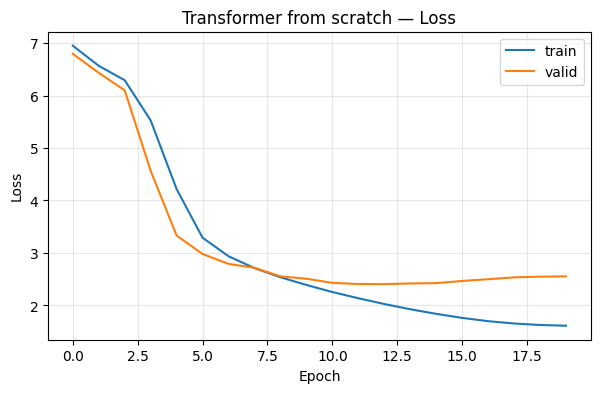

In [11]:
plt.figure(figsize=(7,4))
plt.plot(history['train'], label='train'); plt.plot(history['valid'], label='valid')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Transformer from scratch — Loss'); plt.legend(); plt.grid(alpha=.3)
plt.savefig(cfg.ckpt_dir/'loss.png', dpi=150, bbox_inches='tight'); plt.show()

## 8. Phương thức giải mã (Greedy & Beam Search Decoding)


In [12]:
def _block(seq, no_repeat, logits):
    if no_repeat<=0 or len(seq)<no_repeat: return
    prev=tuple(seq[-(no_repeat-1):])
    for i in range(len(seq)-no_repeat+1):
        ng=tuple(seq[i:i+no_repeat])
        if ng[:-1]==prev: logits[ng[-1]]=float('-inf')

@torch.no_grad()
def greedy_decode(src_ids, max_len=None):
    max_len=max_len or cfg.max_tgt_len; model.eval()
    src=torch.tensor([src_ids], device=device); sm=pad_mask(src,cfg.pad_id); mem=model.encode(src,sm)
    ys=[cfg.bos_id]
    for _ in range(max_len-1):
        cur=torch.tensor([ys], device=device); tm=tgt_mask(cur,cfg.pad_id)
        p_final, _ = model.decode_with_copy(cur, mem, tm, sm, src)
        logit = torch.log(p_final[0,-1].clamp(min=1e-9))
        for tk in set(ys):
            logit[tk] = logit[tk]/cfg.repetition_penalty if logit[tk]>0 else logit[tk]*cfg.repetition_penalty
        _block(ys, cfg.no_repeat_ngram, logit)
        if len(ys)<cfg.min_len: logit[cfg.eos_id]=float('-inf')
        nx=int(logit.argmax()); ys.append(nx)
        if nx==cfg.eos_id: break
    return ys

@torch.no_grad()
def beam_decode(src_ids, beam=None, max_len=None):
    beam=beam or cfg.beam_size; max_len=max_len or cfg.max_tgt_len; model.eval()
    src=torch.tensor([src_ids], device=device); sm=pad_mask(src,cfg.pad_id); mem=model.encode(src,sm)
    beams=[(0.0,[cfg.bos_id])]
    for _ in range(max_len-1):
        cand=[]
        for sc,seq in beams:
            if seq[-1]==cfg.eos_id: cand.append((sc,seq)); continue
            cur=torch.tensor([seq], device=device); tm=tgt_mask(cur,cfg.pad_id)
            p_final, _ = model.decode_with_copy(cur, mem, tm, sm, src)
            lp=torch.log(p_final[0,-1].clamp(min=1e-9))
            _block(seq, cfg.no_repeat_ngram, lp)
            if len(seq)<cfg.min_len: lp[cfg.eos_id]=float('-inf')
            v,i=lp.topk(beam)
            for vv,ii in zip(v.tolist(), i.tolist()): cand.append((sc+vv, seq+[ii]))
        cand.sort(key=lambda x:x[0], reverse=True); beams=cand[:beam]
        if all(s[-1]==cfg.eos_id for _,s in beams): break
    norm=lambda x: x[0]/(((5+len(x[1]))/6)**cfg.length_penalty)
    return max(beams, key=norm)[1]

def ids_to_text(ids):
    return sp.decode([i for i in ids if i not in (cfg.pad_id,cfg.bos_id,cfg.eos_id)])
def summarize(src_ids, method='beam'):
    return ids_to_text(beam_decode(src_ids) if method=='beam' else greedy_decode(src_ids))
print('Decode OK — Pointer-Generator')


Decode OK — Pointer-Generator


## 9. Đánh giá lượng hóa mô hình (Quantitative Evaluation)


In [13]:
from rouge_score import rouge_scorer
import sacrebleu

N_EVAL=300
# Load best weights
sd=torch.load(cfg.ckpt_dir/'best.pt', map_location=device); model.load_state_dict(sd['model']); model.eval()
n=len(valid_src) if N_EVAL is None else min(N_EVAL, len(valid_src))
refs=[ids_to_text(valid_tgt[i].tolist()) for i in range(n)]
preds=[summarize(valid_src[i].tolist(), 'beam') for i in tqdm(range(n), desc='Infer')]

scorer=rouge_scorer.RougeScorer(['rouge1','rouge2','rougeL'], use_stemmer=True)
agg={'rouge1':[],'rouge2':[],'rougeL':[]}
for r,p in zip(refs,preds):
    sc=scorer.score(r,p)
    for k in agg: agg[k].append(sc[k].fmeasure)
rouge={k:sum(v)/len(v) for k,v in agg.items()}
bleu=sacrebleu.corpus_bleu(preds,[refs]).score / 100.0
chrf=sacrebleu.corpus_chrf(preds,[refs]).score / 100.0

results={'ROUGE-1':round(rouge['rouge1'],4),'ROUGE-2':round(rouge['rouge2'],4),
         'ROUGE-L':round(rouge['rougeL'],4),'BLEU':round(bleu,4),'chrF':round(chrf,4)}
try:
    from bert_score import score as bs
    _,_,F1=bs(preds, refs, lang='vi', verbose=False, batch_size=4, device=str(device))
    results['BERTScore-F1']=round(F1.mean().item(),4)
except Exception as e:
    print('BERTScore skip:', e)
print('=== Eval metrics (Scale 0-1) ===')
for k,v in results.items(): print(f'  {k}: {v:.4f}')
json.dump(results, open(cfg.ckpt_dir/'metrics.json','w'))


Infer:   0%|          | 0/300 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


=== Eval metrics (Scale 0-1) ===
  ROUGE-1: 0.7098
  ROUGE-2: 0.3923
  ROUGE-L: 0.4421
  BLEU: 0.2538
  chrF: 0.4250
  BERTScore-F1: 0.7641


## 10. Đánh giá định tính và phân tích lỗi (Qualitative & Error Analysis)


In [14]:
rL=[scorer.score(r,p)['rougeL'].fmeasure for r,p in zip(refs,preds)]
def show(i):
    print('SOURCE:', ids_to_text(valid_src[i].tolist())[:220], '...')
    print('REF   :', refs[i][:220]); print('PRED  :', preds[i][:220]); print('-'*80)
print('### 3 ví dụ ngẫu nhiên')
for i in random.sample(range(n), k=min(3,n)): show(i)
print('### 3 ví dụ ROUGE-L thấp nhất (lỗi điển hình)')
for i in sorted(range(n), key=lambda i:rL[i])[:3]: show(i)

### 3 ví dụ ngẫu nhiên
SOURCE: Trong video Reuters đăng ngày 8/11, một con chó robot được triển khai đi tuần xung quanh khu nghỉ dưỡng Mar-a-Lago. Xuồng tuần tra và cảnh sát có vũ trang cũng liên tục xuất hiện bên ngoài khu phức hợp. Sau khi đắc cử hô ...
REF   : Sau khi đắc cử tổng thống, khu nghỉ dưỡng Mar-a-Lago của Trump được tăng cường an ninh. Một con chó robot được triển khai đi tuần xung quanh khu nghỉ dưỡng, và xuồng tuần tra và cảnh sát có vũ trang cũng xuất hiện bên ng
PRED  : Trong video Reuters, một con chó robot được triển khai đi tuần xung quanh khu nghỉ dưỡng Mar-a-Lago. Xuồng tuần tra và cảnh sát có vũ trang cũng liên tục xuất hiện bên ngoài khu phức hợp. Sau khi đắc cử hôm 6/11, Trump v
--------------------------------------------------------------------------------
SOURCE: Đến Singapore du lịch, giọng ca Gặp lại năm ta 60 có nhiều kỷ niệm đáng nhớ khi dành thời gian trải nghiệm các workshop thủ công của thương hiệu địa phương, tự làm phụ kiện, túi xách. Đây cũng là x

## 11. Chạy dự đoán trên tập kiểm thử (Test Submission)


In [15]:
# ======================================================
# DỰ ĐOÁN TẬP TEST — Chỉ cần sửa TEST_PATH rồi chạy
# ======================================================

TEST_PATH = '/kaggle/input/datasets/thnhnamquch/test-set/test-00000-of-00001.parquet'  # ← Điền đường dẫn file test vào đây (vd: '/kaggle/input/test.parquet')

if TEST_PATH:
    # 1. Đọc dữ liệu test
    test_raw = read_any(Path(TEST_PATH))
    low_t = {c.lower():c for c in test_raw.columns}
    test_src_col = next((low_t[k] for k in SRC if k in low_t), None)
    if test_src_col is None:
        test_src_col = test_raw.columns[0]
        print(f'Không tìm thấy cột source, dùng cột đầu tiên: {test_src_col}')
    test_tgt_col = next((low_t[k] for k in TGT if k in low_t), None)
    has_ref = test_tgt_col is not None
    print(f'Test samples: {len(test_raw)} | Source col: {test_src_col} | Target col: {test_tgt_col}')

    # 2. Encode
    test_texts = test_raw[test_src_col].astype(str).values.tolist()
    if 'clean_text' in globals():
        test_texts = [clean_text(t) for t in test_texts]
    test_src_enc = encode_split(test_texts, cfg.max_src_len, False)

    # 3. Load best model
    sd = torch.load(cfg.ckpt_dir/'best.pt', map_location=device)
    model.load_state_dict(sd['model']); model.eval()
    print(f'Loaded best checkpoint (epoch {sd["epoch"]}, valid_loss={sd["valid"]:.4f})')

    # 4. Dự đoán
    test_preds = []
    for i in tqdm(range(len(test_src_enc)), desc='Predicting'):
        pred = summarize(test_src_enc[i].tolist(), 'beam')
        test_preds.append(pred)

    # 5. Lưu kết quả
    result_df = pd.DataFrame({'source': test_texts, 'prediction': test_preds})

    # 6. Nếu có reference → tính metric (thang 0-1)
    if has_ref:
        from rouge_score import rouge_scorer
        import sacrebleu
        test_refs = test_raw[test_tgt_col].astype(str).values.tolist()
        if 'clean_text' in globals():
            test_refs = [clean_text(r) for r in test_refs]
        result_df['reference'] = test_refs
        scorer = rouge_scorer.RougeScorer(['rouge1','rouge2','rougeL'], use_stemmer=True)
        agg = {'rouge1':[],'rouge2':[],'rougeL':[]}
        for r,p in zip(test_refs, test_preds):
            sc = scorer.score(r,p)
            for k in agg: agg[k].append(sc[k].fmeasure)
        rouge = {k: sum(v)/len(v) for k,v in agg.items()}
        bleu = sacrebleu.corpus_bleu(test_preds, [test_refs]).score / 100.0
        chrf = sacrebleu.corpus_chrf(test_preds, [test_refs]).score / 100.0
        print('=== Test Results (Scale 0-1) ===')
        print(f'  ROUGE-1: {rouge["rouge1"]:.4f}')
        print(f'  ROUGE-2: {rouge["rouge2"]:.4f}')
        print(f'  ROUGE-L: {rouge["rougeL"]:.4f}')
        print(f'  BLEU: {bleu:.4f}')
        print(f'  chrF: {chrf:.4f}')
        try:
            from bert_score import score as bs
            _,_,F1 = bs(test_preds, test_refs, lang='vi', verbose=False, batch_size=4, device=str(device))
            print(f'  BERTScore-F1: {F1.mean().item():.4f}')
        except: pass

    out_path = cfg.ckpt_dir / 'test_predictions.csv'
    result_df.to_csv(out_path, index=False)
    print(f'Đã lưu {len(test_preds)} dự đoán → {out_path}')
else:
    print('No test path provided. Please set TEST_PATH.')


Test samples: 1344 | Source col: article | Target col: summary


Encoding:   0%|          | 0/1344 [00:00<?, ?it/s]

Loaded best checkpoint (epoch 13, valid_loss=2.4053)


Predicting:   0%|          | 0/1344 [00:00<?, ?it/s]

=== Test Results (Scale 0-1) ===
  ROUGE-1: 0.6819
  ROUGE-2: 0.3881
  ROUGE-L: 0.4274
  BLEU: 0.2193
  chrF: 0.3861


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  BERTScore-F1: 0.7601
Đã lưu 1344 dự đoán → /kaggle/working/nlp_bai1/ckpt/test_predictions.csv
